In [2]:
from FeatureCloud.app.engine.app import AppState, app_state, Role
import time
import bios
import pandas as pd
import numpy as np
import sklearn as sk
from sklearn.linear_model import LinearRegression

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from torch import nn
from sklearn.cluster import KMeans
from Autoencoder_classes import Encoder, Decoder, GOAE, ClusteringLayer, extract_latent_space, orthogonality_loss

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from torch import nn
from sklearn.cluster import KMeans

from sklearn.metrics import adjusted_rand_score

In [11]:
df = pd.read_csv('data/real_dataset_normalized.tsv', sep='\t', index_col=0)
df


C:\Users\david\AppData\Local\Temp\ipykernel_17156\658711780.py:1: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/real_dataset_normalized.tsv', sep='\t', index_col=0)


,01CPTAC_1,01CPTAC_2,01CPTAC_3,01CPTAC_4,01CPTAC_5,01CPTAC_6,01CPTAC_7,01CPTAC_8,01CPTAC_9,01CPTAC_10,...,13CPTAC_1,13CPTAC_2,13CPTAC_3,13CPTAC_4,13CPTAC_5,13CPTAC_6,13CPTAC_7,13CPTAC_8,13CPTAC_9,13CPTAC_10
0,0.935603,-0.086369,0.786048,1.069258,0.860449,-0.130177,-0.311762,0.131637,0.537098,1.431399,...,0.632951,1.099141,1.107433,0.974463,1.019426,1.630872,1.682706,0.816556,0.104716,-0.496306
1,1.551572,-0.197678,0.370067,-0.161171,0.359997,-0.262972,-0.413216,0.394467,-0.055829,0.447476,...,1.002573,-0.051359,0.999509,-0.185467,-0.015808,0.012965,-0.818991,-0.60685,-0.62555,0.192115
2,-0.473628,-2.233779,-1.483126,-0.341969,-0.6778,-1.742391,-2.344356,-1.39933,-0.273224,-0.258776,...,1.126813,1.173089,1.45008,0.16036,1.093243,1.152555,0.800632,0.648046,-0.505979,-0.479573
3,0.668724,0.438768,0.518318,0.46211,0.445675,0.481358,0.208015,0.381343,0.464918,0.480309,...,0.736181,0.532446,0.898038,0.501932,0.689904,0.679189,0.620348,0.570685,0.405587,0.540742
4,-1.199512,-2.270995,-2.151234,-1.813642,-2.031302,-1.815763,-1.708907,-2.092016,-2.260684,-1.897957,...,1.491828,0.755135,1.422832,1.76043,1.342536,0.76432,0.765718,1.032165,1.650714,1.483676
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10560,-0.285321951822366,-0.285321951822366,-0.285321951822366,-0.285321951822366,-0.285321951822366,-0.285321951822366,-0.285321951822366,-0.285321951822366,-0.285321951822366,-0.285321951822366,...,-0.285321951822366,-0.285321951822366,-0.285321951822366,-0.285321951822366,-0.285321951822366,-0.285321951822366,-0.285321951822366,-0.285321951822366,-0.285321951822366,-0.285321951822366
10561,1.2446928958307906,-0.18542103396927265,-0.18807113964624592,-0.4326992285610106,-0.5489280354050711,-0.7635051859790253,-1.0006968162223688,-0.19832776679947425,-1.1383480937268962,-0.3398389956764241,...,0.6842244680423223,-1.0940010252406491,1.169143187382292,1.090343890626097,0.19966072783619965,-1.000406893836414,-1.4371923372927784,-0.5007327677267152,-0.9074357528064427,-0.5542534145726915
10562,0.26414242807278165,0.15250367712623575,0.21817441032275073,0.16396493284288707,0.20936256336208922,0.24100416513910672,0.07190893691057308,0.23307358983243565,0.2582638694975213,0.28615078226944496,...,0.5883878164402481,0.33144023011044876,0.3802116564300159,0.5002482193440194,0.33682699641432484,0.3778016385904391,0.25971580883452655,0.29463495531353984,0.18195309388126177,0.1870420162907245
10563,-0.4763250630956321,-1.209986253176779,-0.25758305025144523,-0.6455604351342914,-0.4960141905367187,-1.18325375153811,-0.9426291498872269,-1.0690614771742197,-0.4275900430396228,-0.29720728346551745,...,0.9601407764177715,0.888155089617438,0.8624895414050053,1.1359257532098395,1.1092011180864818,0.7484195407261035,0.9493487260711219,1.1266863464518508,0.7768642993389901,0.7905239938237515


In [22]:
conditions = df.T['Conditions']
sample_data = df.T.drop(columns=['Conditions'])
sample_data

,0,1,2,3,4,5,6,7,8,9,...,10554,10555,10556,10557,10558,10559,10560,10561,10562,10563
01CPTAC_1,0.935603,1.551572,-0.473628,0.668724,-1.199512,0.229795,-1.126011,-1.805717,0.184352,0.867927,...,0.4569293088272782,0.473249894256092,-1.2434474311668966,0.3569417455163055,-0.4940733079086548,-0.017790091556662037,-0.285321951822366,1.2446928958307906,0.26414242807278165,-0.4763250630956321
01CPTAC_2,-0.086369,-0.197678,-2.233779,0.438768,-2.270995,-1.25026,-2.324319,-2.701704,-1.347024,0.704373,...,0.15534962214738657,-0.9157017586739586,-1.2434474311668966,-0.14119030119410508,-0.4940733079086548,-0.469880029527231,-0.285321951822366,-0.18542103396927265,0.15250367712623575,-1.209986253176779
01CPTAC_3,0.786048,0.370067,-1.483126,0.518318,-2.151234,-1.439751,-1.43155,-2.866629,0.272951,0.83598,...,0.058572598007062424,-0.5302627370605081,-1.2434474311668966,0.12440478267380878,-0.4940733079086548,0.010122899250728354,-0.285321951822366,-0.18807113964624592,0.21817441032275073,-0.25758305025144523
01CPTAC_4,1.069258,-0.161171,-0.341969,0.46211,-1.813642,-1.612057,-1.093427,-2.101206,-0.644707,0.662508,...,0.22178725033452124,-0.4259283053455973,-1.2434474311668966,0.09619956475038913,-0.4940733079086548,-0.3021596110209463,-0.285321951822366,-0.4326992285610106,0.16396493284288707,-0.6455604351342914
01CPTAC_5,0.860449,0.359997,-0.6778,0.445675,-2.031302,0.704869,-1.200141,-1.963744,0.006111,0.873364,...,0.20973429622871764,-0.2721946701818993,-1.2434474311668966,0.05789572702811481,-0.4940733079086548,-0.08998775580535515,-0.285321951822366,-0.5489280354050711,0.20936256336208922,-0.4960141905367187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13CPTAC_6,1.630872,0.012965,1.152555,0.679189,0.76432,0.529369,1.784231,1.523567,-0.02789,1.093415,...,0.7630837063704837,1.4719631637354453,0.7829031726029733,0.9030533433063662,-0.4940733079086548,0.6362748187825336,-0.285321951822366,-1.000406893836414,0.3778016385904391,0.7484195407261035
13CPTAC_7,1.682706,-0.818991,0.800632,0.620348,0.765718,0.902489,1.930407,0.653648,0.126765,0.861804,...,0.7019048699407728,2.0225597292143154,0.7272292170240727,0.7706392334040808,-0.4940733079086548,0.9343670154558037,-0.285321951822366,-1.4371923372927784,0.25971580883452655,0.9493487260711219
13CPTAC_8,0.816556,-0.60685,0.648046,0.570685,1.032165,0.435475,-0.049591,0.64221,0.388394,0.849829,...,0.6650138580661155,0.795976052436256,0.6031663603496312,0.8284936564485966,-0.4940733079086548,0.6650859043127806,-0.285321951822366,-0.5007327677267152,0.29463495531353984,1.1266863464518508
13CPTAC_9,0.104716,-0.62555,-0.505979,0.405587,1.650714,1.468639,-0.265719,0.338308,0.110354,0.889028,...,1.3912418278315781,0.14234462709333126,0.6625666804635553,0.9070699608688025,-0.4940733079086548,0.8080970000571848,-0.285321951822366,-0.9074357528064427,0.18195309388126177,0.7768642993389901


In [37]:
##Data Split for 3 clients
part1 = df.iloc[:, :40].T
part2 = df.iloc[:, 40:80].T
part3 = df.iloc[:, 80:130].T

part1_conditions = part1.iloc[:, -1]
part2_conditions = part2.iloc[:, -1]
part3_conditions = part3.iloc[:, -1]

part1.drop(part1.columns[len(part1.columns)-1], axis=1, inplace=True)
part2.drop(part2.columns[len(part2.columns)-1], axis=1, inplace=True)
part3.drop(part3.columns[len(part3.columns)-1], axis=1, inplace=True)

In [15]:
##Data Split for 10 clients
s10_part1 = df.iloc[:, :20].T
s10_part2 = df.iloc[:, 20:40].T
s10_part3 = df.iloc[:, 40:60].T
s10_part4 = df.iloc[:, 60:70].T
s10_part5 = df.iloc[:, 70:80].T
s10_part6 = df.iloc[:, 80:90].T
s10_part7 = df.iloc[:, 90:100].T
s10_part8 = df.iloc[:, 100:110].T
s10_part9 = df.iloc[:, 110:120].T
s10_part10 = df.iloc[:, 120:130].T

s10_part1_conditions = s10_part1.iloc[:, -1]
s10_part2_conditions = s10_part2.iloc[:, -1]
s10_part3_conditions = s10_part3.iloc[:, -1]
s10_part4_conditions = s10_part4.iloc[:, -1]
s10_part5_conditions = s10_part5.iloc[:, -1]
s10_part6_conditions = s10_part6.iloc[:, -1]
s10_part7_conditions = s10_part7.iloc[:, -1]
s10_part8_conditions = s10_part8.iloc[:, -1]
s10_part9_conditions = s10_part9.iloc[:, -1]
s10_part10_conditions = s10_part10.iloc[:, -1]

s10_part1.drop(s10_part1.columns[len(s10_part1.columns)-1], axis=1, inplace=True)
s10_part2.drop(s10_part2.columns[len(s10_part2.columns)-1], axis=1, inplace=True)
s10_part3.drop(s10_part3.columns[len(s10_part3.columns)-1], axis=1, inplace=True)
s10_part4.drop(s10_part4.columns[len(s10_part4.columns)-1], axis=1, inplace=True)
s10_part5.drop(s10_part5.columns[len(s10_part5.columns)-1], axis=1, inplace=True)
s10_part6.drop(s10_part6.columns[len(s10_part6.columns)-1], axis=1, inplace=True)
s10_part7.drop(s10_part7.columns[len(s10_part7.columns)-1], axis=1, inplace=True)
s10_part8.drop(s10_part8.columns[len(s10_part8.columns)-1], axis=1, inplace=True)
s10_part9.drop(s10_part9.columns[len(s10_part9.columns)-1], axis=1, inplace=True)
s10_part10.drop(s10_part10.columns[len(s10_part10.columns)-1], axis=1, inplace=True)
s10_part9

,0,1,2,3,4,5,6,7,8,9,...,10554,10555,10556,10557,10558,10559,10560,10561,10562,10563
12CPTAC_1,0.525724,1.669303,1.322181,0.923639,1.533303,0.547469,-0.076081,0.481977,0.203291,-1.223255,...,0.5469881188787584,1.674750889664657,1.050169949192235,0.7326195254712512,-0.4940733079086548,0.6721924270535078,-0.285321951822366,1.3532844745523462,0.35414369098061194,0.040151289112956526
12CPTAC_2,1.445153,-0.006239,1.989084,1.195584,1.048107,-0.487648,0.968494,0.919507,-0.41422,-1.223255,...,0.33474761072220105,1.1824485287742346,0.7845281126432487,0.2878089833766614,1.7727078431523269,0.7934511664542031,-0.285321951822366,-1.1052262272902784,0.4320591846281381,0.10587488967614953
12CPTAC_3,0.49345,1.269848,0.009016,0.704076,0.854167,1.802305,-0.814799,-0.095868,-0.262107,-1.223255,...,0.39201878298746495,0.0895898569406137,0.8999350498392316,0.7580162337313673,1.8155388232289242,0.46014863738377454,-0.285321951822366,-0.5364949694881634,0.427909842903157,0.10015175135154054
12CPTAC_4,2.013037,2.375926,0.832974,0.834809,1.358379,1.242709,1.182947,0.06186,0.357999,-1.223255,...,0.4781601320451384,0.6250285224196372,0.6959219464734624,0.8058014298597131,-0.4940733079086548,0.5742206589894644,-0.285321951822366,-0.30404278367158605,0.4888016646479306,-0.13690290306758277
12CPTAC_5,1.230442,1.412117,1.452359,1.048122,1.18815,0.6839,-0.275172,0.216718,0.51426,-1.223255,...,0.27901500596803464,1.0290513237887644,1.1179020213537314,0.8354403604831208,-0.4940733079086548,0.5614389073842873,-0.285321951822366,0.8311928570451479,0.3553773352692688,-0.1931276879499379
12CPTAC_6,-1.662102,-0.079295,-1.282599,0.624174,-0.574288,0.133328,-1.396718,-0.656816,-0.264197,-1.223255,...,0.12190000334813032,-1.0193995746027438,0.9167614919311575,0.16008640053149703,2.4599392226316272,0.36221968883739086,-0.285321951822366,-1.2680944393251004,0.1376601284258454,-0.3204933605728208
12CPTAC_7,-0.576154,0.543099,-0.637277,0.500795,0.193101,-0.284982,-1.045447,-0.545804,-0.956645,-1.223255,...,0.7539454439193238,-0.652515865373104,0.6609063913472195,0.18597073769559438,-0.4940733079086548,0.617210146148785,-0.285321951822366,-0.8573741722687963,0.20407591970962533,-0.8949194082876403
12CPTAC_8,0.359924,-0.099519,0.820588,0.859474,0.366212,1.024975,-0.41422,0.167606,-0.237978,-1.223255,...,0.2907551651743067,0.4224553657922331,0.66147488026471,0.2594510292347458,-0.4940733079086548,0.812098549429399,-0.285321951822366,-0.7338595115550632,0.3662951272734121,-0.07793432437642335
12CPTAC_9,2.194476,0.441544,0.339728,0.714929,0.231575,0.580106,-0.388836,0.334493,0.251004,-1.223255,...,0.44104392770987594,0.7370528560034078,0.6741575490692712,0.2014227918859105,-0.4940733079086548,0.7535558235811726,-0.285321951822366,-1.192784958649157,0.407988250699301,-0.020676435068694148
12CPTAC_10,1.235083,-0.088198,1.561503,0.874806,0.269902,-0.273359,0.161203,0.464037,-0.80371,-1.223255,...,0.2877309647260609,0.4083574659934025,0.6453647702301514,0.11802924222746296,-0.4940733079086548,0.7184996621211684,-0.285321951822366,-0.9984950718086587,0.374409279173429,0.04397154510312217


In [38]:
##Export Split 3 Clients
export1 = part1.to_csv('data/client1/realdata.csv', sep=';')
export2 = part2.to_csv('data/client2/realdata.csv', sep=';')
export3 = part3.to_csv('data/client3/realdata.csv', sep=';')
export_meta1 = part1_conditions.to_csv('data/client1/realmetadata.csv', sep=';')
export_meta2 = part2_conditions.to_csv('data/client2/realmetadata.csv', sep=';')
export_meta3 = part3_conditions.to_csv('data/client3/realmetadata.csv', sep=';')

In [16]:
##Export Split 10 Clients
export1 = s10_part1.to_csv('data/client1/10splitrealdata.csv', sep=';')
export2 = s10_part2.to_csv('data/client2/10splitrealdata.csv', sep=';')
export3 = s10_part3.to_csv('data/client3/10splitrealdata.csv', sep=';')
export4 = s10_part4.to_csv('data/client4/10splitrealdata.csv', sep=';')
export5 = s10_part5.to_csv('data/client5/10splitrealdata.csv', sep=';')
export6 = s10_part6.to_csv('data/client6/10splitrealdata.csv', sep=';')
export7 = s10_part7.to_csv('data/client7/10splitrealdata.csv', sep=';')
export8 = s10_part8.to_csv('data/client8/10splitrealdata.csv', sep=';')
export9 = s10_part9.to_csv('data/client9/10splitrealdata.csv', sep=';')
export10 = s10_part10.to_csv('data/client10/10splitrealdata.csv', sep=';')
export_meta1 = s10_part1_conditions.to_csv('data/client1/10splitrealmetadata.csv', sep=';')
export_meta2 = s10_part2_conditions.to_csv('data/client2/10splitrealmetadata.csv', sep=';')
export_meta3 = s10_part3_conditions.to_csv('data/client3/10splitrealmetadata.csv', sep=';')
export_meta3 = s10_part4_conditions.to_csv('data/client4/10splitrealmetadata.csv', sep=';')
export_meta3 = s10_part5_conditions.to_csv('data/client5/10splitrealmetadata.csv', sep=';')
export_meta3 = s10_part6_conditions.to_csv('data/client6/10splitrealmetadata.csv', sep=';')
export_meta3 = s10_part7_conditions.to_csv('data/client7/10splitrealmetadata.csv', sep=';')
export_meta3 = s10_part8_conditions.to_csv('data/client8/10splitrealmetadata.csv', sep=';')
export_meta3 = s10_part9_conditions.to_csv('data/client9/10splitrealmetadata.csv', sep=';')
export_meta3 = s10_part10_conditions.to_csv('data/client10/10splitrealmetadata.csv', sep=';')

In [3]:
df1 = pd.read_csv('data/client1/realmetadata.csv', sep=';', index_col=0)
df1


,Conditions
01CPTAC_1,Not Reported
01CPTAC_2,Primary Tumor
01CPTAC_3,Primary Tumor
01CPTAC_4,Primary Tumor
01CPTAC_5,Primary Tumor
01CPTAC_6,Primary Tumor
01CPTAC_7,Solid Tissue Normal
01CPTAC_8,Primary Tumor
01CPTAC_9,Primary Tumor
01CPTAC_10,Primary Tumor


In [ ]:
df = pd.read_csv('data/real_dataset_normalized.tsv', sep = '\t', index_col=0)
conditions = df.T.drop(columns=['Conditions'])
df = df.T.drop(columns=['Conditions'])
sample_data_normalized = df.reset_index(drop=True).to_numpy(dtype=np.float32)
sample_data_normalized = np.nan_to_num(sample_data_normalized)
proteomics_tensor = torch.tensor(sample_data_normalized, dtype=torch.float32)

input_dim = proteomics_tensor.shape[1]

latent_dim = 10
hidden_dim_1 = 500
hidden_dim_2 = 2000
hidden_dim_3 = 500
n_clusters = 2
autoencoder = GOAE(input_dim, latent_dim, hidden_dim_1=hidden_dim_1, hidden_dim_2=hidden_dim_2, hidden_dim_3=hidden_dim_3)
#clustering_layer = ClusteringLayer(n_clusters, latent_dim)



# Initialize optimizers
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)

autoencoder.load_state_dict(torch.load('data/_state_dict', weights_only=True))

C:\Users\david\AppData\Local\Temp\ipykernel_17156\3243150872.py:1: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/real_dataset_normalized.tsv', sep = '\t', index_col=0)


<All keys matched successfully>

In [4]:
latent_representations = extract_latent_space(autoencoder, proteomics_tensor)
n_clusters = 2
kmeans = KMeans(n_clusters=n_clusters, random_state=22)
clusters = kmeans.fit_predict(latent_representations)

c:\Users\david\Desktop\Biostatistik\Autoencoder\vae\.venv\Lib\site-packages\sklearn\base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


In [1]:
import sys
!{sys.executable} -m pip install matplotlib

  Using cached matplotlib-3.10.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached contourpy-1.3.1-cp311-cp311-win_amd64.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.55.7-cp311-cp311-win_amd64.whl.metadata (102 kB)
  Using cached kiwisolver-1.4.8-cp311-cp311-win_amd64.whl.metadata (6.3 kB)
  Using cached pillow-11.1.0-cp311-cp311-win_amd64.whl.metadata (9.3 kB)
Using cached matplotlib-3.10.0-cp311-cp311-win_amd64.whl (8.0 MB)
Using cached contourpy-1.3.1-cp311-cp311-win_amd64.whl (219 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.55.7-cp311-cp311-win_amd64.whl (2.2 MB)
Using cached kiwisolver-1.4.8-cp311-cp311-win_amd64.whl (71 kB)
Using cached pillow-11.1.0-cp311-cp311-win_amd64.whl (2.6 MB)



[notice] A new release of pip is available: 24.3.1 -> 25.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
conditions = pd.read_csv('data/real_dataset_normalized.tsv', sep = '\t', index_col=0)
conditions = conditions.T.iloc[:, -1]
conditions

C:\Users\david\AppData\Local\Temp\ipykernel_17156\68899831.py:1: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130) have mixed types. Specify dtype option on import or set low_memory=False.
  conditions = pd.read_csv('data/real_dataset_normalized.tsv', sep = '\t', index_col=0)


01CPTAC_1             Not Reported
01CPTAC_2            Primary Tumor
01CPTAC_3            Primary Tumor
01CPTAC_4            Primary Tumor
01CPTAC_5            Primary Tumor
                      ...         
13CPTAC_6            Primary Tumor
13CPTAC_7            Primary Tumor
13CPTAC_8            Primary Tumor
13CPTAC_9      Solid Tissue Normal
13CPTAC_10     Solid Tissue Normal
Name: Conditions, Length: 130, dtype: object

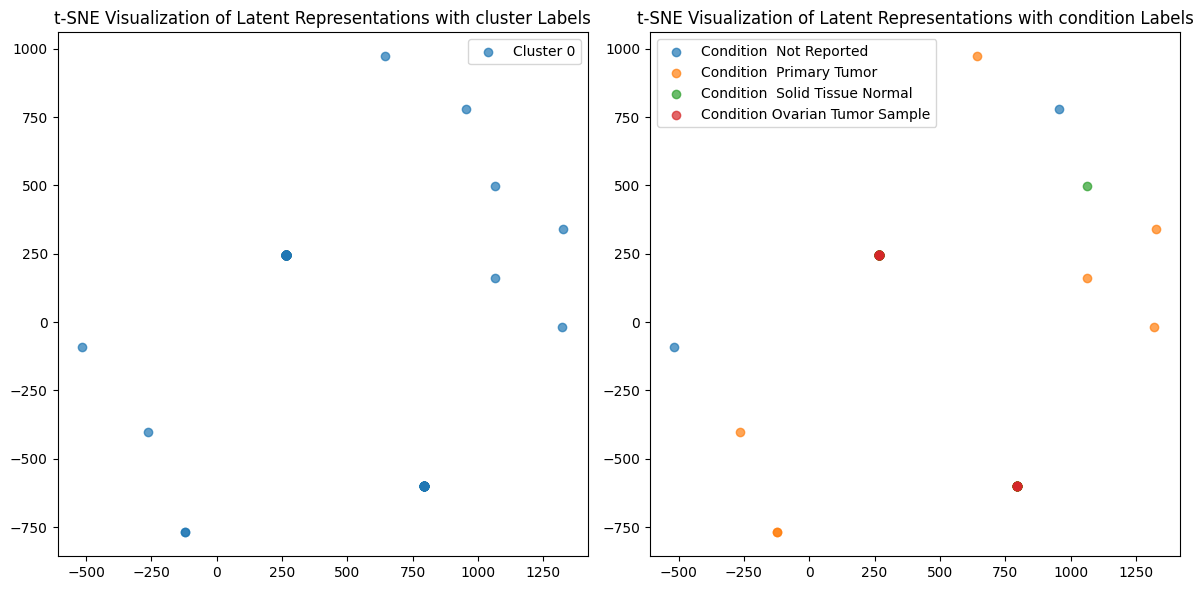

In [9]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, random_state=0)
latent_2d = tsne.fit_transform(latent_representations)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for cluster in set(clusters):
    indices = (clusters == cluster)
    axes[0].scatter(latent_2d[indices, 0], latent_2d[indices, 1], label=f'Cluster {cluster}', alpha=0.7)
axes[0].set_title('t-SNE Visualization of Latent Representations with cluster Labels')
axes[0].legend()

conditions = conditions.values
unique_conditions = np.unique(conditions)
for condition in unique_conditions:
    indices = (conditions == condition)
    axes[1].scatter(
        latent_2d[indices, 0],
        latent_2d[indices, 1],
        label=f'Condition {condition}',
        alpha=0.7
    )
axes[1].set_title('t-SNE Visualization of Latent Representations with condition Labels')
axes[1].legend()

plt.tight_layout()
plt.show()